<a href="https://colab.research.google.com/github/andreelzs/Linguagens-de-programacao/blob/main/analise_streaming_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Engajamento - Plataforma de Streaming
Estudo de Caso: StreamData

## Etapa 1: Leitura e Diagnóstico dos Dados

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

print('Selecione o arquivo streamdata_usuarios.csv:')
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df_stream = pd.read_csv(filename)

Selecione o arquivo streamdata_usuarios.csv:


Saving streamdata_usuarios.csv to streamdata_usuarios.csv


In [2]:
print('Primeiras 5 linhas:')
print(df_stream.head())
print('\nTipos de dados:')
df_stream.info()

Primeiras 5 linhas:
  id_usuario    plano  horas_assistidas dispositivo_principal  \
0   USR-0001   Básico              17.5              Smart TV   
1   USR-0002   Padrão              21.3            Smartphone   
2   USR-0003  Premium              23.9                Tablet   
3   USR-0004   Básico              53.2              Smart TV   
4   USR-0005   Padrão              61.7                Tablet   

   score_satisfacao cancelou_assinatura  
0                 5                 Não  
1                 4                 Não  
2                 4                 Não  
3                 7                 Não  
4                 5                 Sim  

Tipos de dados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_usuario             250 non-null    object 
 1   plano                  250 non-null    object 
 2   hor

## Etapa 2: Média de Horas Assistidas por Plano

In [3]:
media_por_plano = df_stream.groupby('plano')['horas_assistidas'].mean().sort_values()
print(media_por_plano)

plano
Padrão     35.627907
Premium    36.722222
Básico     37.996040
Name: horas_assistidas, dtype: float64


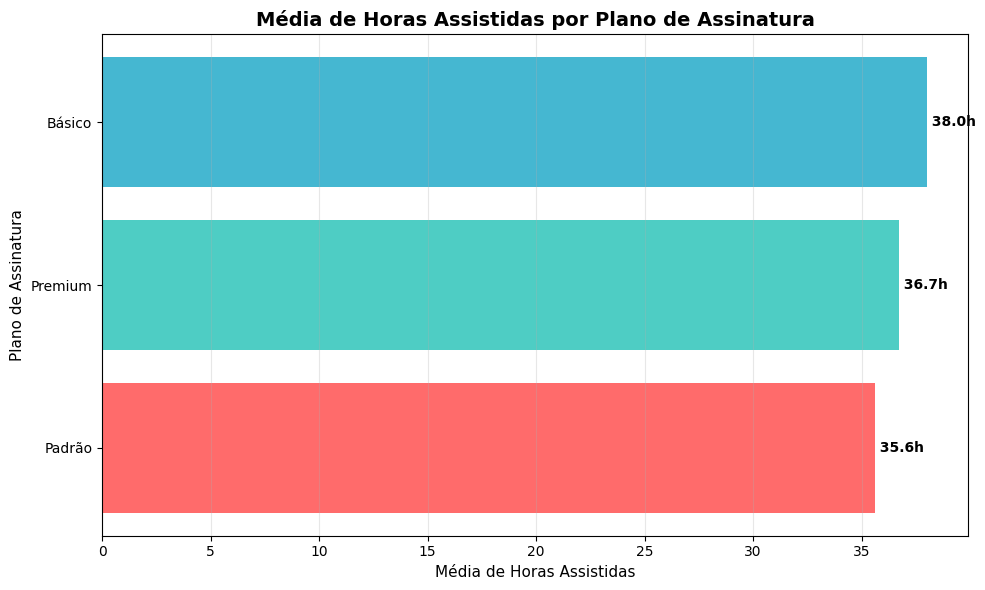

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(media_por_plano.index, media_por_plano.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax.set_xlabel('Média de Horas Assistidas', fontsize=11)
ax.set_ylabel('Plano de Assinatura', fontsize=11)
ax.set_title('Média de Horas Assistidas por Plano de Assinatura', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for i, v in enumerate(media_por_plano.values):
    ax.text(v, i, f' {v:.1f}h', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Etapa 3: Relação entre Satisfação e Cancelamento

In [5]:
cancelados = df_stream[df_stream['cancelou_assinatura'] == 'Sim']['score_satisfacao']
ativos = df_stream[df_stream['cancelou_assinatura'] == 'Não']['score_satisfacao']

print(f'Usuários cancelados: {len(cancelados)}')
print(f'Usuários ativos: {len(ativos)}')
print(f'\nMédia satisfação (cancelados): {cancelados.mean():.2f}')
print(f'Média satisfação (ativos): {ativos.mean():.2f}')

Usuários cancelados: 39
Usuários ativos: 211

Média satisfação (cancelados): 5.31
Média satisfação (ativos): 5.65


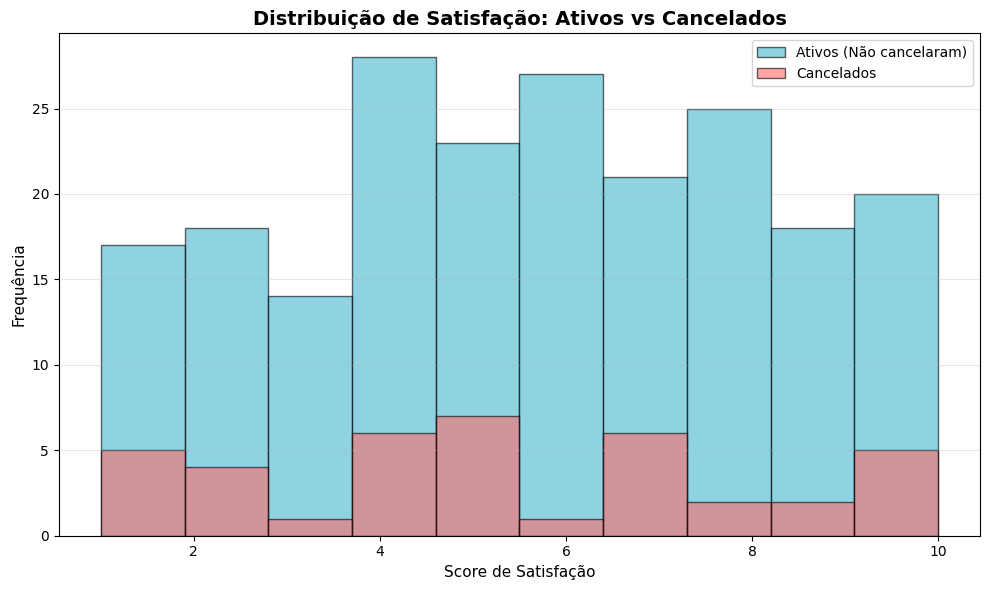

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(ativos, bins=10, alpha=0.6, label='Ativos (Não cancelaram)', color='#45B7D1', edgecolor='black')
ax.hist(cancelados, bins=10, alpha=0.6, label='Cancelados', color='#FF6B6B', edgecolor='black')
ax.set_xlabel('Score de Satisfação', fontsize=11)
ax.set_ylabel('Frequência', fontsize=11)
ax.set_title('Distribuição de Satisfação: Ativos vs Cancelados', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Etapa 4: Distribuição dos Dispositivos Principais

In [7]:
contagem_dispositivos = df_stream['dispositivo_principal'].value_counts()
print(contagem_dispositivos)
print(f'\nTotal: {contagem_dispositivos.sum()}')

dispositivo_principal
Smart TV      71
Computador    68
Smartphone    59
Tablet        52
Name: count, dtype: int64

Total: 250


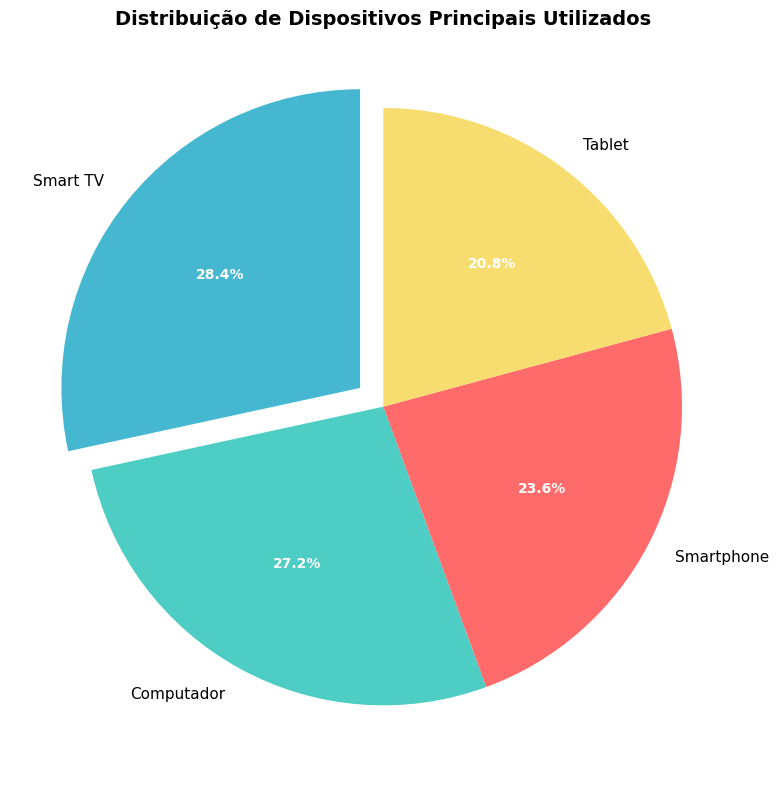

In [8]:
dispositivo_mais_usado = contagem_dispositivos.idxmax()
indice_mais_usado = contagem_dispositivos.index.get_loc(dispositivo_mais_usado)

explode = [0.1 if i == indice_mais_usado else 0 for i in range(len(contagem_dispositivos))]

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#45B7D1', '#4ECDC4', '#FF6B6B', '#F7DC6F']
wedges, texts, autotexts = ax.pie(
    contagem_dispositivos.values,
    labels=contagem_dispositivos.index,
    autopct='%1.1f%%',
    startangle=90,
    explode=explode,
    colors=colors[:len(contagem_dispositivos)],
    textprops={'fontsize': 11}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax.set_title('Distribuição de Dispositivos Principais Utilizados', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Resumo e Insights

In [9]:
print('=' * 50)
print('RESUMO EXECUTIVO - ANÁLISE DE ENGAJAMENTO')
print('=' * 50)

print(f'\n1. CONSUMO POR PLANO (horas/mês):')
for plano, media in media_por_plano.sort_values(ascending=False).items():
    print(f'   {plano}: {media:.1f} horas')

print(f'\n2. TAXA DE CANCELAMENTO:')
taxa_cancel = (len(cancelados) / len(df_stream) * 100)
print(f'   {taxa_cancel:.1f}% dos usuários cancelaram ({len(cancelados)} de {len(df_stream)})')

print(f'\n3. SATISFAÇÃO VS CANCELAMENTO:')
print(f'   Cancelados: satisfação média {cancelados.mean():.1f}/10')
print(f'   Ativos: satisfação média {ativos.mean():.1f}/10')
print(f'   Diferença: {abs(cancelados.mean() - ativos.mean()):.1f} pontos')

print(f'\n4. DISPOSITIVO MAIS UTILIZADO:')
print(f'   {dispositivo_mais_usado} ({contagem_dispositivos[dispositivo_mais_usado]} usuários, {contagem_dispositivos[dispositivo_mais_usado]/len(df_stream)*100:.1f}%)')

print('\n' + '=' * 50)

RESUMO EXECUTIVO - ANÁLISE DE ENGAJAMENTO

1. CONSUMO POR PLANO (horas/mês):
   Básico: 38.0 horas
   Premium: 36.7 horas
   Padrão: 35.6 horas

2. TAXA DE CANCELAMENTO:
   15.6% dos usuários cancelaram (39 de 250)

3. SATISFAÇÃO VS CANCELAMENTO:
   Cancelados: satisfação média 5.3/10
   Ativos: satisfação média 5.7/10
   Diferença: 0.3 pontos

4. DISPOSITIVO MAIS UTILIZADO:
   Smart TV (71 usuários, 28.4%)

